Cell 1-Imports

In [5]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
✅ Libraries loaded


Cell 2-Load Data

In [6]:
# Load the dataset
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Sta

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


cell 3- Basic info

In [7]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n=== DATASET SUMMARY ===")
print(df.describe())

=== DATA TYPES ===
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float

Cell 4-Key coloumns for forcasting

In [8]:
# These are the key columns we'll use
key_cols = [
    'order date (DateOrders)',   # Date
    'Category Name',              # Product category
    'Order Item Quantity',         # What we want to PREDICT
    'Order Item Total',            # Revenue
    'Order Region',                # Geography
    'Shipping Mode',               # Logistics
    'Days for shipping (real)',    # Actual shipping days
    'Days for shipment (scheduled)', # Scheduled shipping days
    'Late_delivery_risk'           # Our anomaly target
]

df_selected = df[key_cols].copy()
print(df_selected.head(10))
print(f"\nSelected shape: {df_selected.shape}")

  order date (DateOrders)   Category Name  Order Item Quantity  \
0         1/31/2018 22:56  Sporting Goods                    1   
1         1/13/2018 12:27  Sporting Goods                    1   
2         1/13/2018 12:06  Sporting Goods                    1   
3         1/13/2018 11:45  Sporting Goods                    1   
4         1/13/2018 11:24  Sporting Goods                    1   
5         1/13/2018 11:03  Sporting Goods                    1   
6         1/13/2018 10:42  Sporting Goods                    1   
7         1/13/2018 10:21  Sporting Goods                    1   
8         1/13/2018 10:00  Sporting Goods                    1   
9          1/13/2018 9:39  Sporting Goods                    1   

   Order Item Total    Order Region   Shipping Mode  Days for shipping (real)  \
0        314.640015  Southeast Asia  Standard Class                         3   
1        311.359985      South Asia  Standard Class                         5   
2        309.720001      South

cell 5-Visualize Demand over Time

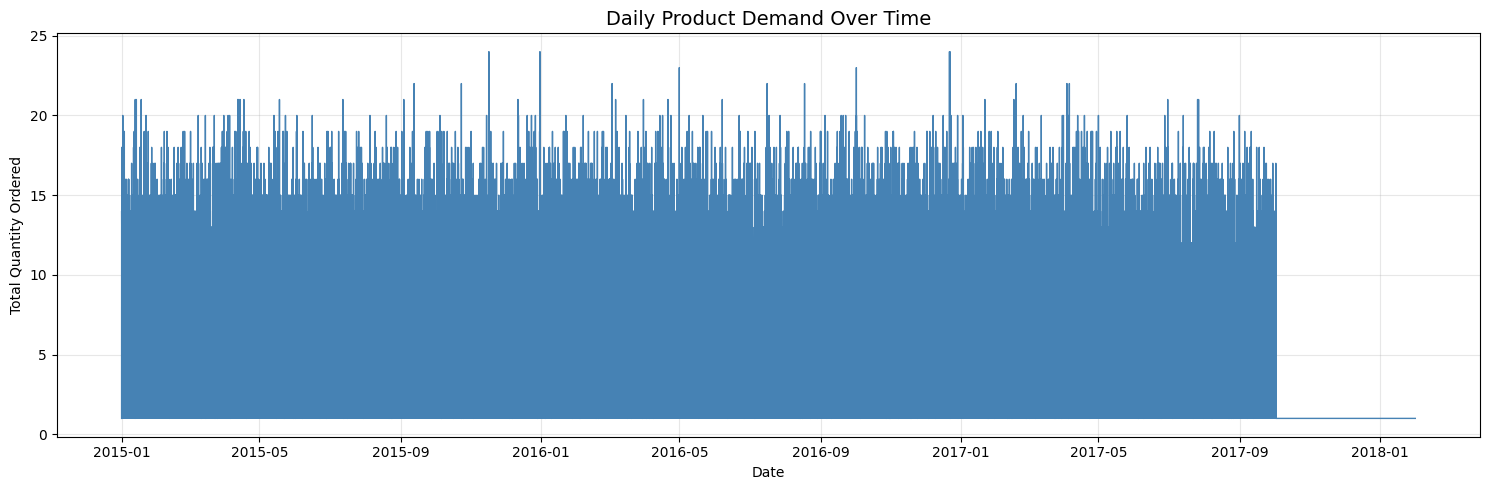

✅ Demand trend chart saved


In [9]:
# Convert date column
df_selected['order date (DateOrders)'] = pd.to_datetime(
    df_selected['order date (DateOrders)']
)

# Group by date - daily demand
daily_demand = df_selected.groupby('order date (DateOrders)')['Order Item Quantity'].sum().reset_index()
daily_demand.columns = ['date', 'quantity']

plt.figure(figsize=(15, 5))
plt.plot(daily_demand['date'], daily_demand['quantity'], color='steelblue', linewidth=1)
plt.title('Daily Product Demand Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Quantity Ordered')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/demand_trend.png')
plt.show()
print("✅ Demand trend chart saved")

Cell 6-Check Late Delivery Rate

Late Delivery Risk Distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


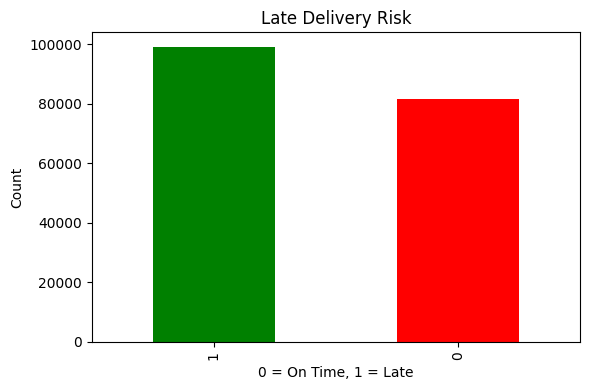

In [10]:
# Late delivery analysis
late_counts = df_selected['Late_delivery_risk'].value_counts()
print("Late Delivery Risk Distribution:")
print(late_counts)

plt.figure(figsize=(6, 4))
late_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Late Delivery Risk')
plt.xlabel('0 = On Time, 1 = Late')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/late_delivery.png')
plt.show()